# Melbourne Housing Price Prediction
## Machine Learning Regression Project

This project predicts housing prices using the Melbourne Housing Dataset. It includes data cleaning, missing value handling, feature engineering, encoding, Linear Regression model building, and evaluation.

## Workflow

```text
Load Data → Data Cleaning → Missing Value Handling → Encoding → Feature Engineering → Train/Test Split → Model Training → Evaluation
```

## Import Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.linear_model import LinearRegression
import warnings
warnings.filterwarnings('ignore')

## Load Dataset

In [ ]:
df = pd.read_csv("Melbourne_housing_.csv")
df

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra,-37.80140,144.99580,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.79960,144.99840,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.00,Yarra,-37.80790,144.99340,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra,-37.81140,145.01160,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.00,Yarra,-37.80930,144.99440,Northern Metropolitan,4019.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
19735,Windsor,201/152 Peel St,2,u,560000.0,PI,hockingstuart,29/07/2017,4.6,3181.0,...,1.0,1.0,NaN,585.0,NaN,Whittlesea,-37.67681,145.00323,Southern Metropolitan,4380.0
19736,Wollert,60 Saltlake Bvd,3,h,525300.0,S,Stockdale,29/07/2017,25.5,3750.0,...,2.0,2.0,NaN,333.0,NaN,Darebin,-37.75884,145.00264,Northern Metropolitan,2940.0
19737,Yarraville,2 Adeney St,2,h,750000.0,SP,hockingstuart,29/07/2017,6.3,3013.0,...,2.0,2.0,1999.0,199.0,140.00,Darebin,-37.75948,144.99615,Western Metropolitan,6543.0
19738,Yarraville,54 Pentland Pde,6,h,2450000.0,VB,Village,29/07/2017,6.3,3013.0,...,2.0,1.0,2011.0,238.0,118.00,Hume,-37.70322,144.88236,Western Metropolitan,6543.0


In [3]:
df.head()

,Suburb,Address,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,...,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
0,Abbotsford,68 Studley St,2,h,NaN,SS,Jellis,3/09/2016,2.5,3067.0,...,1.0,1.0,126.0,NaN,NaN,Yarra,-37.8014,144.9958,Northern Metropolitan,4019.0
1,Abbotsford,85 Turner St,2,h,1480000.0,S,Biggin,3/12/2016,2.5,3067.0,...,1.0,1.0,202.0,NaN,NaN,Yarra,-37.7996,144.9984,Northern Metropolitan,4019.0
2,Abbotsford,25 Bloomburg St,2,h,1035000.0,S,Biggin,4/02/2016,2.5,3067.0,...,1.0,0.0,156.0,79.0,1900.0,Yarra,-37.8079,144.9934,Northern Metropolitan,4019.0
3,Abbotsford,18/659 Victoria St,3,u,NaN,VB,Rounds,4/02/2016,2.5,3067.0,...,2.0,1.0,0.0,NaN,NaN,Yarra,-37.8114,145.0116,Northern Metropolitan,4019.0
4,Abbotsford,5 Charles St,3,h,1465000.0,SP,Biggin,4/03/2017,2.5,3067.0,...,2.0,0.0,134.0,150.0,1900.0,Yarra,-37.8093,144.9944,Northern Metropolitan,4019.0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 19740 entries, 0 to 19739
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Suburb         19740 non-null  object 
 1   Address        19740 non-null  object 
 2   Rooms          19740 non-null  int64  
 3   Type           19740 non-null  object 
 4   Price          15396 non-null  float64
 5   Method         19740 non-null  object 
 6   SellerG        19740 non-null  object 
 7   Date           19740 non-null  object 
 8   Distance       19732 non-null  float64
 9   Postcode       19732 non-null  float64
 10  Bedroom2       15327 non-null  float64
 11  Bathroom       15327 non-null  float64
 12  Car            15327 non-null  float64
 13  Landsize       14944 non-null  float64
 14  BuildingArea   8617 non-null   float64
 15  YearBuilt      9351 non-null   float64
 16  CouncilArea    15296 non-null  object 
 17  Lattitude      15448 non-null  float64
 18  Longti

In [5]:
df.describe()

,Rooms,Price,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,Lattitude,Longtitude,Propertycount
count,19740.000000,1.539600e+04,19732.000000,19732.000000,15327.000000,15327.000000,15327.000000,14944.000000,8617.000000,9351.000000,15448.000000,15448.000000,19732.000000
mean,2.947163,1.054957e+06,9.861509,3106.533904,2.900568,1.548509,1.578065,583.917090,196.806973,1874.165655,-37.811892,144.996632,7509.802706
std,0.981048,6.452557e+05,5.554233,88.429928,1.007491,0.713385,0.972221,3785.423175,561.558007,393.354888,0.072708,0.096178,4419.678648
min,1.000000,8.500000e+04,0.000000,3000.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,-38.182550,144.431620,249.000000
25%,2.000000,6.300000e+05,6.100000,3046.000000,2.000000,1.000000,1.000000,166.000000,94.000000,1930.000000,-37.856860,144.939323,4407.000000
50%,3.000000,8.800000e+05,9.200000,3101.000000,3.000000,1.000000,2.000000,420.000000,132.000000,1965.000000,-37.808965,145.000900,6567.000000
75%,4.000000,1.301000e+06,12.600000,3147.000000,3.000000,2.000000,2.000000,663.000000,199.000000,1997.000000,-37.761897,145.054710,10331.000000
max,12.000000,9.000000e+06,47.400000,3978.000000,30.000000,12.000000,26.000000,433014.000000,40468.000000,2106.000000,-37.413810,145.526350,21650.000000


In [6]:
df.columns

Index(['Suburb', 'Address', 'Rooms', 'Type', 'Price', 'Method', 'SellerG',
       'Date', 'Distance', 'Postcode', 'Bedroom2', 'Bathroom', 'Car',
       'Landsize', 'BuildingArea', 'YearBuilt', 'CouncilArea', 'Lattitude',
       'Longtitude', 'Regionname', 'Propertycount'],
      dtype='object')

In [7]:
for i in df.columns:
    print(f"{i} : {df[i].unique()}")

Suburb : ['Abbotsford' 'Airport West' 'Albert Park' 'Alphington' 'Altona'
 'Altona North' 'Armadale' 'Ascot Vale' 'Ashburton' 'Ashwood'
 'Avondale Heights' 'Balaclava' 'Balwyn' 'Balwyn North' 'Bentleigh'
 'Bentleigh East' 'Box Hill' 'Braybrook' 'Brighton' 'Brighton East'
 'Brunswick' 'Brunswick West' 'Bulleen' 'Burwood' 'Camberwell'
 'Canterbury' 'Carlton North' 'Carnegie' 'Caulfield' 'Caulfield North'
 'Caulfield South' 'Chadstone' 'Clifton Hill' 'Coburg' 'Coburg North'
 'Collingwood' 'Doncaster' 'Eaglemont' 'Elsternwick' 'Elwood' 'Essendon'
 'Essendon North' 'Fairfield' 'Fitzroy' 'Fitzroy North' 'Flemington'
 'Footscray' 'Glen Iris' 'Glenroy' 'Gowanbrae' 'Hadfield' 'Hampton'
 'Hampton East' 'Hawthorn' 'Heidelberg Heights' 'Heidelberg West'
 'Hughesdale' 'Ivanhoe' 'Kealba' 'Keilor East' 'Kensington' 'Kew'
 'Kew East' 'Kooyong' 'Maidstone' 'Malvern' 'Malvern East' 'Maribyrnong'
 'Melbourne' 'Middle Park' 'Mont Albert' 'Moonee Ponds' 'Moorabbin'
 'Newport' 'Niddrie' 'North Melbourne' 'N

In [8]:
for i in df.columns:
    print(f"{i} : {df[i].nunique()}")

Suburb : 330
Address : 19403
Rooms : 11
Type : 3
Price : 2298
Method : 9
SellerG : 308
Date : 52
Distance : 209
Postcode : 204
Bedroom2 : 13
Bathroom : 10
Car : 13
Landsize : 1541
BuildingArea : 915
YearBuilt : 372
CouncilArea : 33
Lattitude : 5927
Longtitude : 6538
Regionname : 8
Propertycount : 325


In [9]:
df.drop(columns="Address",inplace=True)

## Missing Value Handling

In [10]:
x = df.isna().sum()
x[x > 0]

Price             4344
Distance             8
Postcode             8
Bedroom2          4413
Bathroom          4413
Car               4413
Landsize          4796
BuildingArea     11123
YearBuilt        10389
CouncilArea       4444
Lattitude         4292
Longtitude        4292
Regionname           8
Propertycount        8
dtype: int64

In [11]:
df[df["Distance"].isna()]

,Suburb,Rooms,Type,Price,Method,SellerG,Date,Distance,Postcode,Bedroom2,Bathroom,Car,Landsize,BuildingArea,YearBuilt,CouncilArea,Lattitude,Longtitude,Regionname,Propertycount
18146,MacLeod,3,h,682000.0,S,Barry,12/08/2017,NaN,NaN,4.0,3.0,2.0,575.0,NaN,NaN,Banyule,-37.77336,145.05829,Eastern Metropolitan,NaN
18522,Footscray Lot,2,u,710000.0,S,Jas,15/07/2017,NaN,NaN,3.0,1.0,3.0,621.0,NaN,1955.0,Casey,-37.98537,145.23505,NaN,NaN
18591,MacLeod,4,h,825000.0,PI,Purplebricks,15/07/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18592,MacLeod,2,u,770000.0,S,Nelson,15/07/2017,NaN,NaN,2.0,1.0,2.0,1955.0,498.0,75.0,Banyule,-37.73759,145.04236,NaN,NaN
19040,MacLeod,3,u,NaN,SN,Miles,22/07/2017,NaN,NaN,4.0,2.0,2.0,1998.0,719.0,719.0,Bayside,-37.94999,145.03122,NaN,NaN
19041,MacLeod,3,h,910000.0,S,Ray,22/07/2017,NaN,NaN,2.0,1.0,3.0,1950.0,716.0,142.0,Bayside,-37.95023,145.03081,NaN,NaN
19042,MacLeod,3,h,710000.0,S,Ray,22/07/2017,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
19542,MacLeod,3,h,1210000.0,S,Darren,29/07/2017,NaN,NaN,3.0,1.0,2.0,1965.0,628.0,NaN,Monash,-37.90904,145.10903,NaN,NaN


In [12]:
print(len(df))
df = df.dropna(subset=["Distance","Postcode","Regionname","Propertycount"])
print(len(df))

19740
19731


In [13]:
x = df.isna().sum()
x[x > 0]

Price            4343
Bedroom2         4410
Bathroom         4410
Car              4410
Landsize         4793
BuildingArea    11118
YearBuilt       10384
CouncilArea      4441
Lattitude        4289
Longtitude       4289
dtype: int64

In [14]:
null_percent = ((df.isna().sum() / len(df)) * 100).round(3)

null_percent[null_percent > 0]

Price           22.011
Bedroom2        22.351
Bathroom        22.351
Car             22.351
Landsize        24.292
BuildingArea    56.348
YearBuilt       52.628
CouncilArea     22.508
Lattitude       21.737
Longtitude      21.737
dtype: float64

<Axes: >

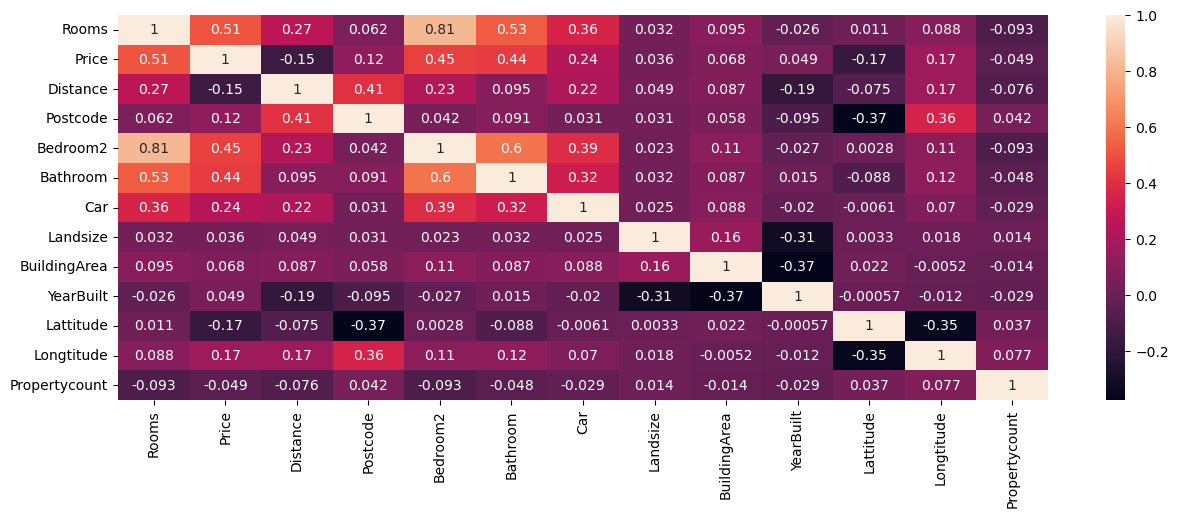

In [15]:
plt.figure(figsize=(15,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [16]:
df.drop(columns=["BuildingArea"], inplace=True)

## Random Imputation for YearBuilt

In [17]:
null_mask = df["YearBuilt"].isna()

df.loc[null_mask, "YearBuilt"] = np.random.choice(
    df["YearBuilt"].dropna(),
    size=null_mask.sum()
)

In [18]:
# Drop rows where target variable is missing
df = df.dropna(subset=["Price"])

In [19]:
# Categorical column
df["CouncilArea"] = df["CouncilArea"].fillna(
    df["CouncilArea"].mode()[0]
)

In [20]:
null_col = ((df.isna().sum() / len(df)) * 100).round(3)
cols = (null_col[null_col>0]).index

In [21]:
for i in cols:
    df[i] = df[i].fillna(df[i].median())

In [22]:
df.isna().sum() 

Suburb           0
Rooms            0
Type             0
Price            0
Method           0
SellerG          0
Date             0
Distance         0
Postcode         0
Bedroom2         0
Bathroom         0
Car              0
Landsize         0
YearBuilt        0
CouncilArea      0
Lattitude        0
Longtitude       0
Regionname       0
Propertycount    0
dtype: int64

In [23]:
df_objects = df.select_dtypes(include=object)
df_objects

,Suburb,Type,Method,SellerG,Date,CouncilArea,Regionname
1,Abbotsford,h,S,Biggin,3/12/2016,Yarra,Northern Metropolitan
2,Abbotsford,h,S,Biggin,4/02/2016,Yarra,Northern Metropolitan
4,Abbotsford,h,SP,Biggin,4/03/2017,Yarra,Northern Metropolitan
5,Abbotsford,h,PI,Biggin,4/03/2017,Yarra,Northern Metropolitan
6,Abbotsford,h,VB,Nelson,4/06/2016,Yarra,Northern Metropolitan
...,...,...,...,...,...,...,...
19735,Windsor,u,PI,hockingstuart,29/07/2017,Whittlesea,Southern Metropolitan
19736,Wollert,h,S,Stockdale,29/07/2017,Darebin,Northern Metropolitan
19737,Yarraville,h,SP,hockingstuart,29/07/2017,Darebin,Western Metropolitan
19738,Yarraville,h,VB,Village,29/07/2017,Hume,Western Metropolitan


In [24]:
for i in df_objects.columns:
    print(i,df_objects[i].nunique())

Suburb 320
Type 3
Method 5
SellerG 278
Date 52
CouncilArea 33
Regionname 8


In [25]:
freq = df["Suburb"].value_counts()

df["Suburb_freq"] = df["Suburb"].map(freq)
df.drop(columns=["Suburb"], inplace=True)

In [26]:
df = pd.get_dummies(df,columns=["Type", "Method"],drop_first=True)

In [27]:
freq = df["SellerG"].value_counts()

df["SellerG_freq"] = df["SellerG"].map(freq)
df.drop(columns=["SellerG"],inplace=True)

In [28]:
df["Date"] = pd.to_datetime(df["Date"],dayfirst=True)

df["Year"] = df["Date"].dt.year
df["Month"] = df["Date"].dt.month
df["Day"] = df["Date"].dt.day

In [29]:
df.drop(columns=["Date"], inplace=True)

In [30]:
freq = df["CouncilArea"].value_counts()

df["CouncilArea_freq"] = df["CouncilArea"].map(freq)
df.drop(columns=["CouncilArea"],inplace=True)

In [31]:
df = pd.get_dummies(df,columns=["Regionname"],drop_first=True)

In [32]:
df.dtypes

Rooms                                      int64
Price                                    float64
Distance                                 float64
Postcode                                 float64
Bedroom2                                 float64
Bathroom                                 float64
Car                                      float64
Landsize                                 float64
YearBuilt                                float64
Lattitude                                float64
Longtitude                               float64
Propertycount                            float64
Suburb_freq                                int64
Type_t                                      bool
Type_u                                      bool
Method_S                                    bool
Method_SA                                   bool
Method_SP                                   bool
Method_VB                                   bool
SellerG_freq                               int64
Year                

## Feature and Target Selection

In [33]:
x = df.drop(columns=["Price"])
y = df["Price"]

## Train Test Split

In [34]:
xtrain,xtest,ytrain,ytest = train_test_split(x,y,train_size=0.75,random_state=42)
xtrain,xtest,ytrain,ytest

(       Rooms  Distance  Postcode  Bedroom2  Bathroom  Car  Landsize  \
 372        1       6.3    3143.0       1.0       1.0  0.0       0.0   
 6844       3       6.9    3039.0       3.0       2.0  2.0     597.0   
 9262       2       3.3    3141.0       2.0       2.0  1.0       0.0   
 17931      3      12.1    3083.0       3.0       1.0  1.0     412.0   
 19383      3      20.6    3064.0       3.0       2.0  1.0    1950.0   
 ...      ...       ...       ...       ...       ...  ...       ...   
 6801       2      11.8    3127.0       2.0       1.0  1.0       0.0   
 17260      2       2.4    3121.0       2.0       1.0  0.0     164.0   
 7035       4       8.4    3015.0       4.0       3.0  2.0     233.0   
 1102       5       9.2    3104.0       3.0       1.0  1.0     412.0   
 9376       1       3.3    3141.0       3.0       1.0  1.0     412.0   
 
        YearBuilt  Lattitude  Longtitude  ...  Month  Day  CouncilArea_freq  \
 372       1975.0  -37.85300   145.01670  ...     12   

## Model Training

In [35]:
mlr = LinearRegression()

In [36]:
mlr.fit(xtrain, ytrain)

LinearRegression()

In [37]:
mlr.coef_

array([ 2.39664267e+05, -4.84168562e+04,  4.52274194e+02, -2.87238624e+04,
        1.69423432e+05,  4.50402303e+04,  7.52381309e+00,  1.00817172e+01,
       -4.46961768e+05, -1.65974567e+05, -4.13338854e-01, -7.30707781e+01,
       -2.97790061e+05, -4.96749722e+05,  7.51416088e+04,  3.33280758e+04,
        2.89691255e+04,  3.34191051e+04,  1.51799540e+01,  8.80440268e+04,
        7.75996592e+03,  4.75608857e+02,  3.97275584e+01,  2.76989275e+05,
       -2.30954879e+05,  1.54319197e+05,  1.50141841e+05,  1.88155325e+05,
       -2.82326090e+05, -1.21961804e+05])

In [38]:
mlr.intercept_

np.float64(-171157077.17207545)

## Prediction and Evaluation

In [39]:
ypred = mlr.predict(xtest)
ypred

array([1154020.59039649, 1139531.2412346 , 1075157.50343961, ...,
       1514778.34195545, 1674672.16327006, 1200536.7665754 ])

In [40]:
mae = mean_absolute_error(ytest,ypred)
mae

284798.15324090346

In [41]:
mse = mean_squared_error(ytest,ypred)
mse

177839807734.40756

In [42]:
rmse = np.sqrt(mse)
rmse

np.float64(421710.5734202162)

In [43]:
r2 = r2_score(ytest,ypred)
r2

0.58719500296007

## Conclusion

This project demonstrates a complete Machine Learning regression workflow using the Melbourne Housing Dataset.The Linear Regression model achieved an R² score of approximately 0.58, meaning the model explains around 58% of the variance in house prices.

Although the model provides moderate prediction performance, the project establishes a strong foundation for applying advanced regression algorithms such as Random Forest and XGBoost to further improve accuracy.

Overall, this project highlights the importance of preprocessing, feature engineering, and proper evaluation in building effective Machine Learning models.